In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dockerDF = pd.read_csv('../docker-gpuData.csv')

hostDF = pd.read_csv('../host-gpuData.csv')

In [3]:
print(dockerDF.columns)
print(dockerDF.shape)

print(hostDF.columns)
print(hostDF.shape)

Index(['source', 'exePath', 'kernel_executed', 'eteProfilerXtime', 'CC',
       'Kernel Name', 'traffic', 'bytesRead', 'bytesWrite', 'bytesTotal',
       'dpAI', 'spAI', 'hpAI', 'dpPerf', 'spPerf', 'hpPerf', 'xtime',
       'Block Size', 'Grid Size', 'device', 'SP_FLOP', 'DP_FLOP', 'HP_FLOP',
       'INTOP', 'intPerf', 'intAI', 'targetName', 'exeArgs', 'runtime',
       'kernelMangled', 'kernelName', 'kernelDemangled', 'kernelProfiler'],
      dtype='object')
(2511, 33)
Index(['source', 'exePath', 'kernel_executed', 'eteProfilerXtime', 'CC',
       'Kernel Name', 'traffic', 'bytesRead', 'bytesWrite', 'bytesTotal',
       'dpAI', 'spAI', 'hpAI', 'dpPerf', 'spPerf', 'hpPerf', 'xtime',
       'Block Size', 'Grid Size', 'device', 'SP_FLOP', 'DP_FLOP', 'HP_FLOP',
       'INTOP', 'intPerf', 'intAI', 'targetName', 'exeArgs', 'runtime',
       'kernelMangled', 'kernelName', 'kernelDemangled', 'kernelProfiler'],
      dtype='object')
(2487, 33)


In [4]:
# let's drop rows with specific null values in specific columns
dockerDF = dockerDF.dropna(how='any', axis=0, subset=['traffic', 'CC'])
hostDF = hostDF.dropna(how='any', axis=0, subset=['traffic', 'CC'])

print(dockerDF.shape)
print(hostDF.shape)

# drop any rows that don't have a "normal" value for the "kernel_executed" column
dockerDF = dockerDF[dockerDF['kernel_executed'] == 'normal']
hostDF = hostDF[hostDF['kernel_executed'] == 'normal']

print(dockerDF.shape)
print(hostDF.shape)

(1817, 33)
(1816, 33)
(1817, 33)
(1816, 33)


In [5]:
print(hostDF.iloc[0])

source                                                  accuracy-cuda
exePath             /home/gbolet/gpuFLOPBench-updated/build/bin/cu...
kernel_executed                                                normal
eteProfilerXtime                                             2.420618
CC                                                                8.6
Kernel Name                            _Z15accuracy_kerneliiiPKfPKiPi
traffic                                           645338847117.790039
bytesRead                                                 327821568.0
bytesWrite                                                  1765888.0
bytesTotal                                                329587456.0
dpAI                                                              0.0
spAI                                                              0.0
hpAI                                                              0.0
dpPerf                                                            0.0
spPerf              

In [6]:
print(dockerDF.iloc[0])

source                                                  accuracy-cuda
exePath                            /workspace/build/bin/cuda/accuracy
kernel_executed                                                normal
eteProfilerXtime                                             2.644247
CC                                                                8.6
Kernel Name                            _Z15accuracy_kerneliiiPKfPKiPi
traffic                                           642171799027.550049
bytesRead                                                 327821440.0
bytesWrite                                                  1833600.0
bytesTotal                                                329655040.0
dpAI                                                              0.0
spAI                                                              0.0
hpAI                                                              0.0
dpPerf                                                            0.0
spPerf              

In [7]:
# the "traffic" metric is in the units of bytes/sec, so let's convert it to bytes
# by multiplying by the kernel execution time (xtime) -- need to scale it out of (ns)

dockerDF['trafficBytes'] = dockerDF['traffic'] * dockerDF['xtime'] * 1e-9
hostDF['trafficBytes'] = hostDF['traffic'] * hostDF['xtime'] * 1e-9

In [8]:
# we want to align both dataframes based on the "kernelMangled" and "source" columns
mergedDF = pd.merge(hostDF, dockerDF, on=['kernelMangled', 'Kernel Name', 'kernelName', 'kernelDemangled', 
                                          'kernelProfiler', 'targetName', 'CC', 'runtime', 'source', 'exeArgs',
                                          'device', 'Block Size', 'Grid Size'], suffixes=('_host', '_docker'))

print(mergedDF.columns)
print(mergedDF.shape)

mergedDF.sort_values(by=['targetName', 'source'], ascending=True, inplace=True)

print(mergedDF.head(4))

print(mergedDF['kernel_executed_docker'].unique())

# drop any rows where kernel_executed_host or kernel_executed_docker is NOT "normal"
mergedDF = mergedDF[(mergedDF['kernel_executed_host'] == 'normal') & (mergedDF['kernel_executed_docker'] == 'normal')]
print(mergedDF.shape)

print(mergedDF.iloc[0])

Index(['source', 'exePath_host', 'kernel_executed_host',
       'eteProfilerXtime_host', 'CC', 'Kernel Name', 'traffic_host',
       'bytesRead_host', 'bytesWrite_host', 'bytesTotal_host', 'dpAI_host',
       'spAI_host', 'hpAI_host', 'dpPerf_host', 'spPerf_host', 'hpPerf_host',
       'xtime_host', 'Block Size', 'Grid Size', 'device', 'SP_FLOP_host',
       'DP_FLOP_host', 'HP_FLOP_host', 'INTOP_host', 'intPerf_host',
       'intAI_host', 'targetName', 'exeArgs', 'runtime', 'kernelMangled',
       'kernelName', 'kernelDemangled', 'kernelProfiler', 'trafficBytes_host',
       'exePath_docker', 'kernel_executed_docker', 'eteProfilerXtime_docker',
       'traffic_docker', 'bytesRead_docker', 'bytesWrite_docker',
       'bytesTotal_docker', 'dpAI_docker', 'spAI_docker', 'hpAI_docker',
       'dpPerf_docker', 'spPerf_docker', 'hpPerf_docker', 'xtime_docker',
       'SP_FLOP_docker', 'DP_FLOP_docker', 'HP_FLOP_docker', 'INTOP_docker',
       'intPerf_docker', 'intAI_docker', 'trafficBytes_d

In [9]:
cmembench_data = mergedDF[(mergedDF['targetName'] == 'cmembench') & (mergedDF['source'] == 'cmembench-cuda')]

print(cmembench_data.shape)
print(cmembench_data)

(3, 55)
             source                                       exePath_host  \
196  cmembench-cuda  /home/gbolet/gpuFLOPBench-updated/build/bin/cu...   
197  cmembench-cuda  /home/gbolet/gpuFLOPBench-updated/build/bin/cu...   
198  cmembench-cuda  /home/gbolet/gpuFLOPBench-updated/build/bin/cu...   

    kernel_executed_host  eteProfilerXtime_host   CC  \
196               normal              16.283795  8.6   
197               normal              16.283795  8.6   
198               normal              16.283795  8.6   

                           Kernel Name  traffic_host  bytesRead_host  \
196      _Z18benchmark_constantIiEvPii    3030639.77          9216.0   
197  _Z18benchmark_constantI4int2EvPii    3026329.06          9216.0   
198  _Z18benchmark_constantI4int4EvPii    2601267.13          7936.0   

     bytesWrite_host  bytesTotal_host  ...  spPerf_docker  hpPerf_docker  \
196            384.0           9600.0  ...            0.0            0.0   
197            384.0         

['exePath_host', 'kernel_executed_host', 'eteProfilerXtime_host', 'traffic_host', 'bytesRead_host', 'bytesWrite_host', 'bytesTotal_host', 'dpAI_host', 'spAI_host', 'hpAI_host', 'dpPerf_host', 'spPerf_host', 'hpPerf_host', 'xtime_host', 'SP_FLOP_host', 'DP_FLOP_host', 'HP_FLOP_host', 'INTOP_host', 'intPerf_host', 'intAI_host', 'trafficBytes_host']
['exePath_docker', 'kernel_executed_docker', 'eteProfilerXtime_docker', 'traffic_docker', 'bytesRead_docker', 'bytesWrite_docker', 'bytesTotal_docker', 'dpAI_docker', 'spAI_docker', 'hpAI_docker', 'dpPerf_docker', 'spPerf_docker', 'hpPerf_docker', 'xtime_docker', 'SP_FLOP_docker', 'DP_FLOP_docker', 'HP_FLOP_docker', 'INTOP_docker', 'intPerf_docker', 'intAI_docker', 'trafficBytes_docker']
['DP_FLOP', 'HP_FLOP', 'INTOP', 'SP_FLOP', 'bytesRead', 'bytesTotal', 'bytesWrite', 'dpAI', 'dpPerf', 'eteProfilerXtime', 'exePath', 'hpAI', 'hpPerf', 'intAI', 'intPerf', 'kernel_executed', 'spAI', 'spPerf', 'traffic', 'trafficBytes', 'xtime']


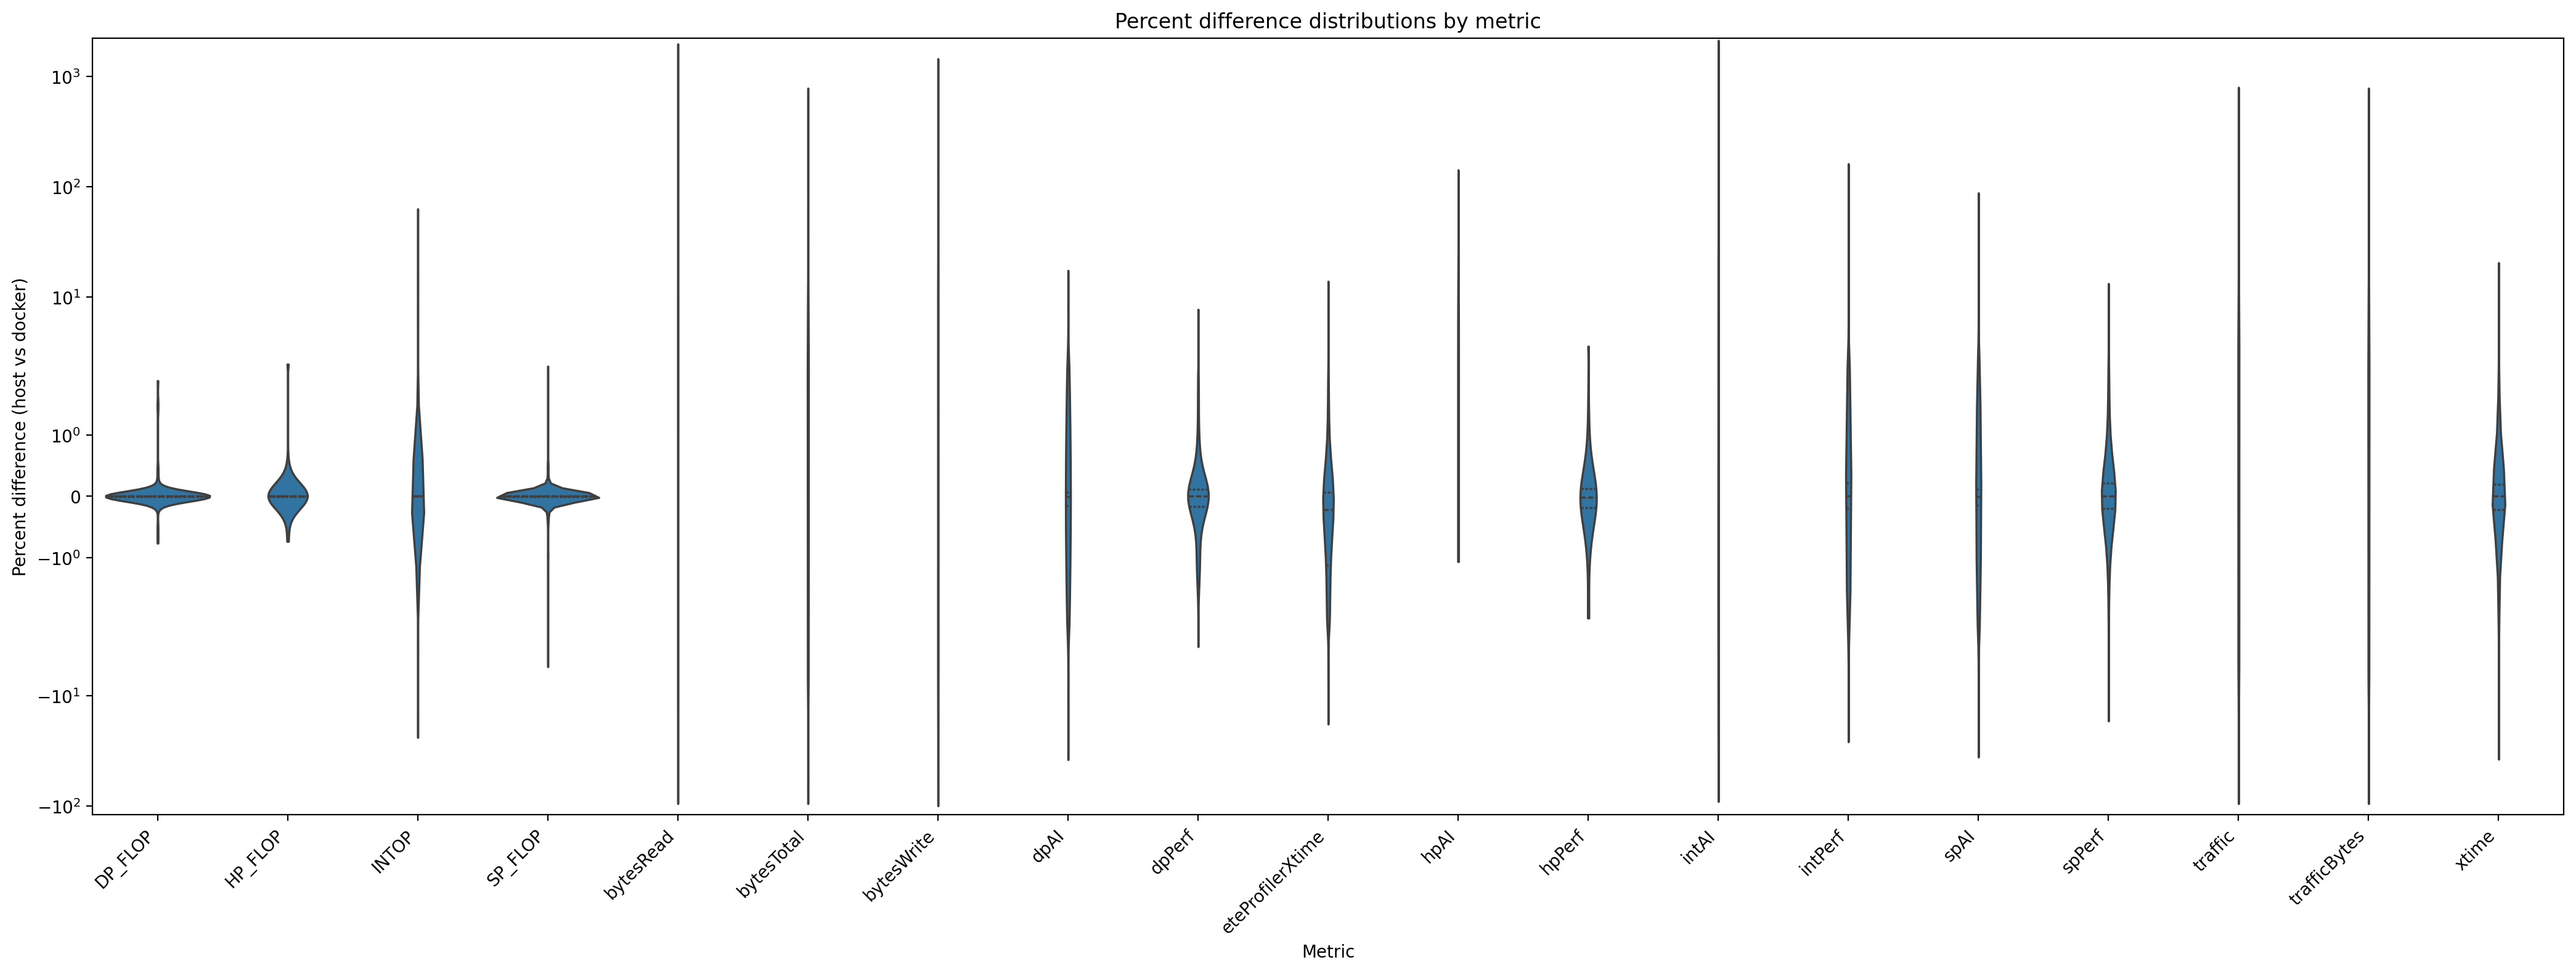

In [10]:
# make violin seaborn plots here

# identify numeric *_host / *_docker pairs
host_cols = [c for c in mergedDF.columns if c.endswith('_host')]
docker_cols = [c for c in mergedDF.columns if c.endswith('_docker')]

print(host_cols)
print(docker_cols)

base_cols = sorted(set(c[:-5] for c in host_cols).intersection(c[:-7] for c in docker_cols))

print(base_cols)

records = []
for base in base_cols:
    host_col = f"{base}_host"
    docker_col = f"{base}_docker"
    if host_col not in mergedDF.columns or docker_col not in mergedDF.columns:
        continue
    # ensure numeric and drop invalid rows
    host_vals = pd.to_numeric(mergedDF[host_col], errors='coerce')
    docker_vals = pd.to_numeric(mergedDF[docker_col], errors='coerce')

    valid = (~host_vals.isna()) & (~docker_vals.isna()) 
    if valid.any():
        pct_diff = (host_vals[valid] - docker_vals[valid]) / docker_vals[valid] * 100.0
        records.append(pd.DataFrame({"metric": base, "pct_diff": pct_diff}))

if not records:
    print("No matching *_host/*_docker numeric columns found for plotting.")
else:
    plot_df = pd.concat(records, ignore_index=True)
    plt.figure(figsize=(max(8, len(base_cols)), 8), dpi=200)
    ax = sns.violinplot(data=plot_df, x="metric", y="pct_diff", inner="quartile", cut=0)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Percent difference (host vs docker)")
    ax.set_title("Percent difference distributions by metric")

    ax.set_yscale("symlog")
    ax.set_ylim(bottom=-120)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [11]:
# build a detailed dataframe for largest percent differences
detail_records = []
for base in base_cols:
    host_col = f"{base}_host"
    docker_col = f"{base}_docker"
    if host_col not in mergedDF.columns or docker_col not in mergedDF.columns:
        continue
    host_vals = pd.to_numeric(mergedDF[host_col], errors="coerce")
    docker_vals = pd.to_numeric(mergedDF[docker_col], errors="coerce")
    valid = (~host_vals.isna()) & (~docker_vals.isna())
    if not valid.any():
        continue
    pct = (host_vals[valid] - docker_vals[valid]) / docker_vals[valid] * 100.0
    temp = pd.DataFrame({
        "metric": base,
        "source": mergedDF.loc[valid, "source"].values,
        "targetName": mergedDF.loc[valid, "targetName"].values,
        "Kernel Name": mergedDF.loc[valid, "Kernel Name"].values,
        "Block Size": mergedDF.loc[valid, "Block Size"].values,
        "Grid Size": mergedDF.loc[valid, "Grid Size"].values,
        "host_value": host_vals[valid].values,
        "docker_value": docker_vals[valid].values,
        "pct_diff": pct.values,
    })
    detail_records.append(temp)

if not detail_records:
    print("No detailed percent-difference records to inspect.")
else:
    diff_df = pd.concat(detail_records, ignore_index=True)
    diff_df = diff_df.replace([np.inf, -np.inf], np.nan)
    diff_df = diff_df.dropna(subset=["pct_diff"])
    diff_df["abs_pct_diff"] = diff_df["pct_diff"].abs()
    diff_df = diff_df.sort_values("abs_pct_diff", ascending=False)

    print("Largest percent differences (host vs docker):")
    print(diff_df.head(100)[["metric", "source", "targetName", 
                             "Kernel Name", "Block Size", "Grid Size",
                             "host_value", "docker_value", 
                             "pct_diff"]].to_string(index=False))

Largest percent differences (host vs docker):
      metric                 source        targetName                                                                      Kernel Name  Block Size       Grid Size   host_value  docker_value    pct_diff
       intAI   atomicAggregate-cuda   atomicAggregate                                                                          _Z1kPii (256, 1, 1)   (65536, 1, 1) 1.172846e+05  5.262769e+03 2128.571433
   bytesRead  atomicSystemWide-cuda  atomicSystemWide                                                              _Z12atomicKernelPii (256, 1, 1)      (64, 1, 1) 1.090560e+05  5.248000e+03 1978.048780
   bytesRead  atomicIntrinsics-cuda  atomicIntrinsics                                                           _Z10testKernelIiEvPT_m (256, 1, 1)  (524288, 1, 1) 8.857600e+04  4.864000e+03 1721.052632
  bytesWrite    particlefilter-cuda    particlefilter                                          _Z17kernel_find_indexPKfS0_S0_S0_PfS1_i (256, 1, 1)

In [12]:
# although the "traffic" metric and "intAI" metric differ a lot for atomicPerf-cuda on the "_Z28SingleRangeAtomicOnSharedMemIdEvPT_ii" kernel,
# it is doing <double> operations, and that's what we care about. The amount of work, given the block and grid size doesn't seem too small,
# so it might not be "noise". Let's look at the DPFLOPs to see if those differ too.

atomicPerfCuda_data = mergedDF[(mergedDF['targetName'] == 'atomicPerf') & (mergedDF['source'] == 'atomicPerf-cuda') & (mergedDF['Kernel Name'] == '_Z28SingleRangeAtomicOnSharedMemIdEvPT_ii')]

print(atomicPerfCuda_data.shape)

print(atomicPerfCuda_data[['DP_FLOP_host', 'DP_FLOP_docker', 'intAI_host', 'intAI_docker', 'trafficBytes_host', 'trafficBytes_docker']])

# print the DP_FLOP percent difference for this kernel
host_dpflop = pd.to_numeric(atomicPerfCuda_data['DP_FLOP_host'], errors='coerce')
docker_dpflop = pd.to_numeric(atomicPerfCuda_data['DP_FLOP_docker'], errors='coerce')   
pct_dpflop = (host_dpflop - docker_dpflop) / docker_dpflop * 100.0
print("DP_FLOP percent difference (host vs docker):")
print(pct_dpflop)

# what we can see if that the percent difference in DP_FLOP is small (~0.03%), indicating that the actual work done is similar,
# even though the "intAI" and "traffic" metrics differ significantly. 

(1, 55)
    DP_FLOP_host  DP_FLOP_docker    intAI_host  intAI_docker  \
81   118071201.0     117898628.0  79891.502584   73647.47357   

    trafficBytes_host  trafficBytes_docker  
81        3072.000001          3327.999999  
DP_FLOP percent difference (host vs docker):
81    0.146374
dtype: float64
